In [ ]:
# here we are using optuna for doing hyperparameter tunning
# in this only two parameter are hypertuned - num_hidden_layers,neuron_pr_layer

In [ ]:
# importing the dependencies
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# setting random seed for reproducibility
torch.manual_seed(42)

In [ ]:
# check for gpu
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# loading the dataset from kaggle server to google colab
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
fashionmnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/fashionmnist.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
df = pd.read_csv('/content/fashion-mnist_train.csv')

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


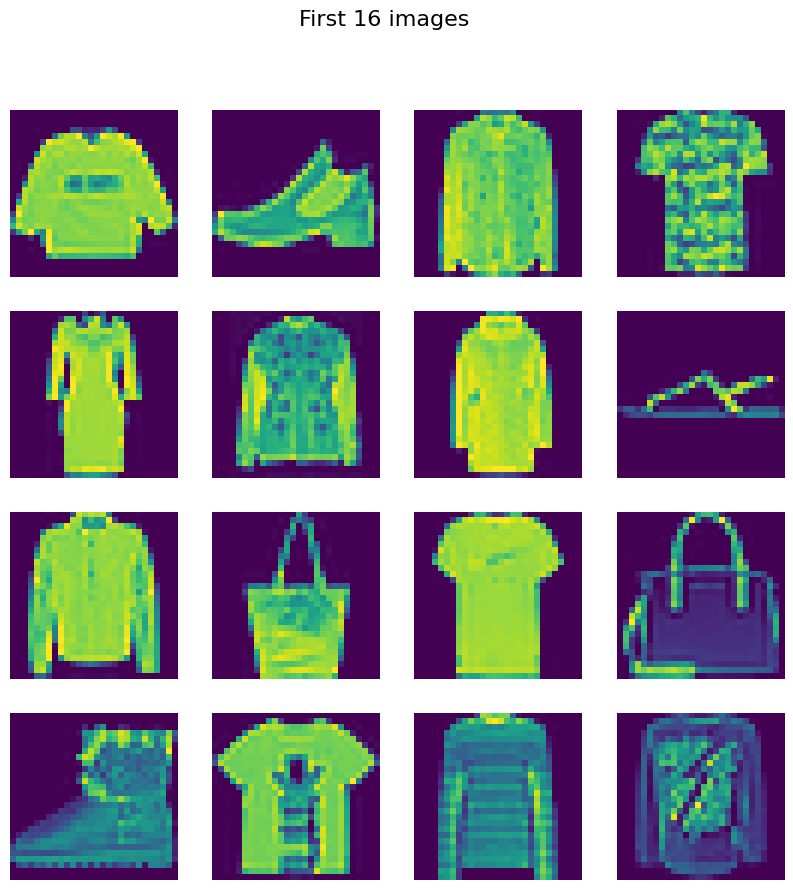

In [ ]:
# visualizing images images in 4x4 grid
fig,axes = plt.subplots(4,4,figsize=(10,10))
plt.suptitle("First 16 images",fontsize=16)

# ploting
for i,ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

In [ ]:
# separating the features and target
x = df.drop(columns = ['label'],axis=1)
y = df['label']

In [ ]:
x

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,5,0,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,1,2,0,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,0,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,0,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
y

,label
0,2
1,9
2,6
3,0
4,3
...,...
59995,9
59996,1
59997,8
59998,8


In [ ]:
# train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# normalize
x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(60000, 784) (48000, 784) (12000, 784)


In [ ]:
# creating our custommDataset calss for shuffling,gpu loading ,efficient data access

class customDataset(Dataset):

  def __init__(self,features,labels):

    # convert to Pytorch tensors
    self.features = torch.tensor(features,dtype=torch.float32)
    self.labels = torch.tensor(labels,dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]

In [ ]:
# train data is converted into a PyTorch-compatible dataset
# As PyTorch cannot directly work with Pandas or NumPy in training/evaluation loops
train_dataset = customDataset(x_train.values,y_train.values)

In [ ]:
# test data is converted into a PyTorch-compatible dataset
test_dataset = customDataset(x_test.values,y_test.values)

In [ ]:
# As Neural networks do not train on entire data at once we use DataLoader to create mini batches
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

In [ ]:
print(len(train_loader))
print(len(test_loader))

1500
375


**Hyperparameter tunning using optuna**

In [ ]:
class MyNN(nn.Module):

  def __init__(self,input_dim,output_dim,num_hidden_layers,neuron_per_layer):

    # calling parent constructor
    super().__init__()

    layers = []   # to append the hidden layers nad activation function

    for i in range(num_hidden_layers):
      layers.append(nn.Linear(input_dim,neuron_per_layer))
      layers.append(nn.BatchNorm1d(neuron_per_layer))
      layers.append(nn.ReLU())
      layers.append(nn.Dropout(0.2))
      input_dim = neuron_per_layer

    layers.append(nn.Linear(neuron_per_layer,output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self,x):
    return self.model(x)


In [ ]:
# objective function

def objective(trial):

  # next hyperparameter value from the search space
  num_hidden_layers = trial.suggest_int("num_hidden_layers",1,5)
  neuron_per_layer = trial.suggest_int("neuron_per_layer",8,128,step=8)

  # model init
  input_dim = 784
  output_dim = 10

  model = MyNN(input_dim,output_dim,num_hidden_layers,neuron_per_layer)
  model.to(device)

  # params init
  learning_rate = 0.1
  epochs = 50

  # optimizer selection

  # loss function
  criterion = nn.CrossEntropyLoss()
  # optimizer
  optimizer = optim.SGD(model.parameters(),lr = learning_rate,weight_decay=1e-4)

  # training loop

  for epoch in range (epochs):

    for batch_features,batch_labels in train_loader:

      # move data to gpu
      batch_features = batch_features.to(device)
      batch_labels = batch_labels.to(device)

      # forward pass
      output = model(batch_features)

      # calculate loss
      loss = criterion(output,batch_labels)

      # back pass
      optimizer.zero_grad()   # clear the old gradient
      loss.backward()

      # update grads
      optimizer.step()


    # evaluation
    total = 0
    correct = 0

    with torch.no_grad():

      for batch_features,batch_labels in test_loader:

        # moving features,labels to gpu
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device) # Corrected: ensure labels are moved, not overwritten by features

        output = model(batch_features)

        _,predicted = torch.max(output,1)

        total = total + batch_labels.size(0)

        correct = correct + (predicted == batch_labels).sum().item()

    accuracy = (correct/total)

  return accuracy


In [ ]:
learning_rate = 0.1
epochs = 100

**Creating study**

In [ ]:
!pip install optuna

In [ ]:
import optuna
study = optuna.create_study(direction='maximize')

[I 2026-01-09 11:54:22,033] A new study created in memory with name: no-name-6763c958-f882-44b4-bbfe-02b5f6aa3a25


In [ ]:
study.optimize(objective,n_trials=10)

[I 2026-01-09 11:59:07,460] Trial 0 finished with value: 0.8611666666666666 and parameters: {'num_hidden_layers': 4, 'neuron_per_layer': 80}. Best is trial 0 with value: 0.8611666666666666.
[I 2026-01-09 12:04:17,500] Trial 1 finished with value: 0.8565 and parameters: {'num_hidden_layers': 5, 'neuron_per_layer': 72}. Best is trial 0 with value: 0.8611666666666666.
[I 2026-01-09 12:09:26,233] Trial 2 finished with value: 0.8630833333333333 and parameters: {'num_hidden_layers': 5, 'neuron_per_layer': 112}. Best is trial 2 with value: 0.8630833333333333.
[I 2026-01-09 12:14:34,824] Trial 3 finished with value: 0.8421666666666666 and parameters: {'num_hidden_layers': 5, 'neuron_per_layer': 48}. Best is trial 2 with value: 0.8630833333333333.
[I 2026-01-09 12:19:43,984] Trial 4 finished with value: 0.8530833333333333 and parameters: {'num_hidden_layers': 5, 'neuron_per_layer': 72}. Best is trial 2 with value: 0.8630833333333333.
[I 2026-01-09 12:23:37,367] Trial 5 finished with value: 0.86

In [ ]:
study.best_value

0.8665833333333334

In [ ]:
study.best_params

{'num_hidden_layers': 3, 'neuron_per_layer': 96}